# Proyecto Integrador: Predicción del Riesgo de Abandono Académico en Estudiantes Universitarios

**Módulo:** 2.10 Proyecto Integrador de Aprendizaje Automático (k-NN)  
**Dataset:** Predict Students' Dropout and Academic Success (UCI - ID 697)  
**Objetivo:** Construir un modelo k-NN para predecir el riesgo de abandono académico utilizando datos demográficos, socioeconómicos y académicos.

---

## 1. Configuración del Entorno e Importación de Datos

### 1.1 Instalación del paquete ucimlrepo

El paquete `ucimlrepo` permite acceder directamente a los datasets del UCI Machine Learning Repository desde Python.

In [4]:
pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### 1.2 Importación del dataset

Utilizamos `fetch_ucirepo` con el ID 697 para obtener el dataset de predicción de abandono y éxito académico.

In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# data (as pandas dataframes)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

# metadata
print(predict_students_dropout_and_academic_success.metadata)

# variable information
print(predict_students_dropout_and_academic_success.variables)

{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

### 1.3 Librerías necesarias

Importamos las librerías para análisis, visualización y modelado.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

# Configuración de visualización
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")
%matplotlib inline

---

## 2. Exploración de Datos (EDA)

Analizamos la estructura del dataset, valores faltantes y distribución de variables.

In [7]:
# Unir features y target para análisis completo
df = pd.concat([X, y], axis=1)

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
df.head(10)

Dimensiones del dataset: (4424, 37)

Primeras filas:


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [8]:
print("Información del dataset:")
df.info()
print("\nValores faltantes por columna:")
print(df.isnull().sum())
print("\nEstadísticas descriptivas:")
df.describe()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualifi

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### 2.1 Distribución de la variable objetivo

El dataset tiene 3 clases: **Dropout** (abandono), **Enrolled** (matriculado) y **Graduate** (graduado). Existe desbalance hacia una de las clases.

In [9]:
target_col = df.columns[-1]
print("Distribución de la variable objetivo:")
print(df[target_col].value_counts())
print("\nProporciones:")
print(df[target_col].value_counts(normalize=True).round(3))

Distribución de la variable objetivo:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Proporciones:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


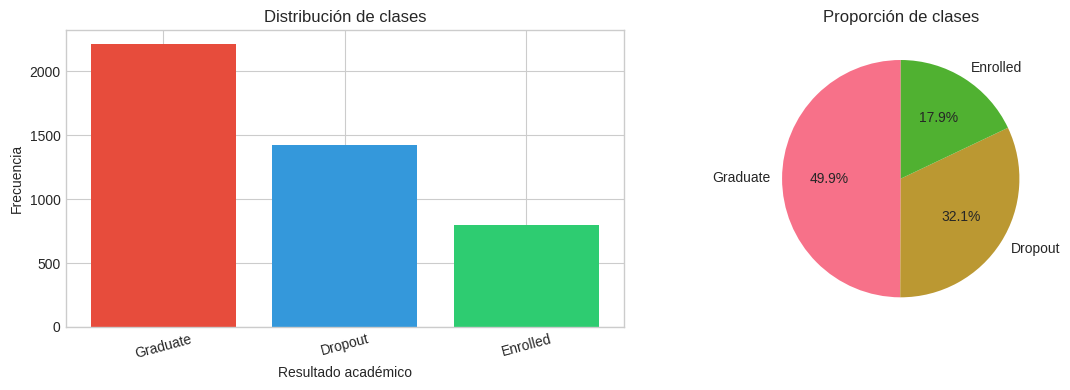

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
counts = df[target_col].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_xlabel('Resultado académico')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de clases')
axes[0].tick_params(axis='x', rotation=15)

# Gráfico de pastel
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

### 2.2 Visualización de variables numéricas clave

Seleccionamos variables demográficas y académicas relevantes para el análisis.

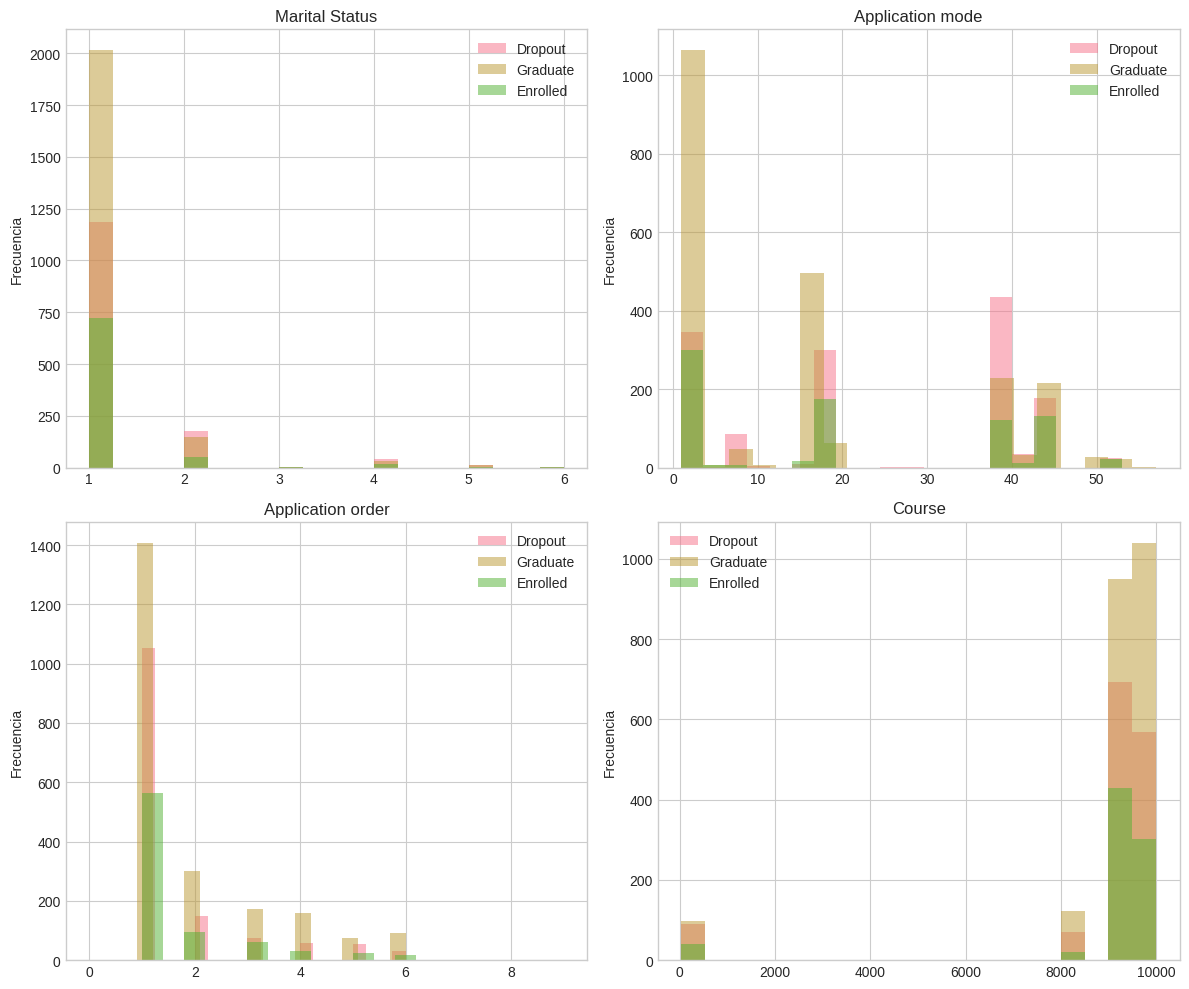

In [11]:
# Variables numéricas de interés (seleccionamos las primeras numéricas disponibles)
numeric_vars = [c for c in df.select_dtypes(include=[np.number]).columns if c != df.columns[-1]][:4]

if numeric_vars:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    for i, var in enumerate(numeric_vars):
        for outcome in df[target_col].unique():
            subset = df[df[target_col] == outcome][var]
            axes[i].hist(subset, alpha=0.5, label=outcome, bins=20)
        axes[i].set_ylabel('Frecuencia')
        axes[i].set_title(var)
        axes[i].legend()
    plt.tight_layout()
    plt.show()

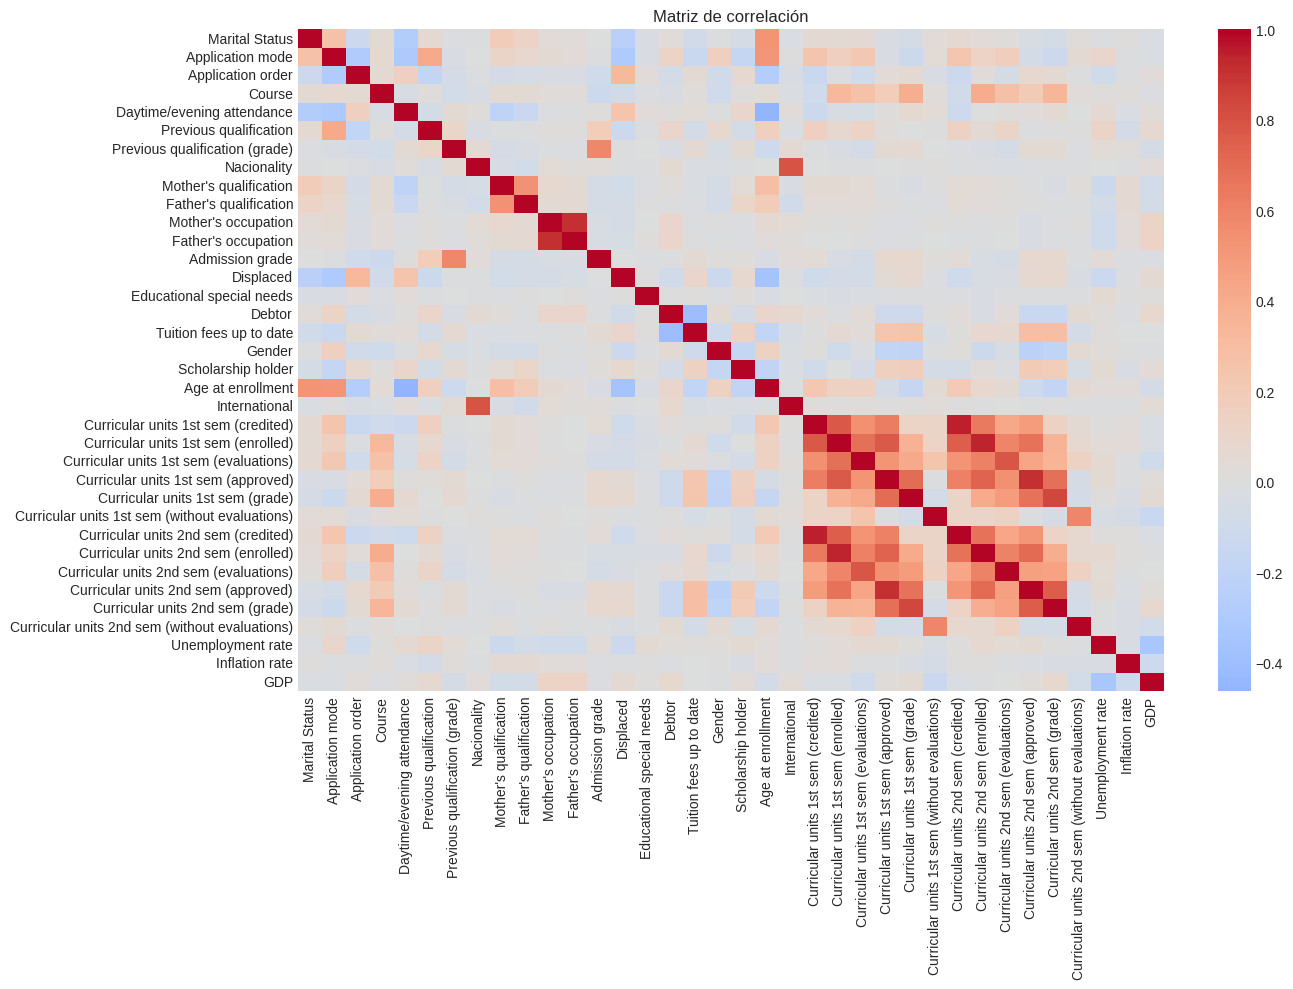

In [12]:
# Matriz de correlación de variables numéricas
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 1:
    plt.figure(figsize=(14, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Matriz de correlación')
    plt.tight_layout()
    plt.show()

---

## 3. Preprocesamiento

**Justificación:** k-NN es sensible a la escala de las variables. Aplicamos estandarización (StandardScaler) para que todas las variables contribuyan por igual. Además, codificamos la variable objetivo si es categórica.

In [13]:
# Separar features y target
X = df.drop(columns=[target_col])
y = df[target_col]

# Codificar variable objetivo si es categórica
if y.dtype == 'object' or y.dtype.name == 'category':
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    print("Clases codificadas:", dict(zip(le.classes_, le.transform(le.classes_))))
else:
    y_encoded = y.values
    le = None

# División train/test (80% train, 20% test - según recomendación del dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dimensiones entrenamiento:", X_train.shape)
print("Dimensiones prueba:", X_test.shape)

Clases codificadas: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Dimensiones entrenamiento: (3539, 36)
Dimensiones prueba: (885, 36)


---

## 4. Modelo k-NN

### 4.1 Entrenamiento inicial

**Justificación de k-NN:** k-NN es un algoritmo no paramétrico que clasifica según la mayoría de los k vecinos más cercanos. Es adecuado para este problema porque no asume linealidad y puede capturar patrones complejos en datos demográficos y académicos.

In [21]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("Accuracy (k=5):", round(accuracy_score(y_test, y_pred), 4))
print("\nReporte de clasificación:")
class_names = le.classes_ if le else [str(i) for i in np.unique(y_encoded)]
print(classification_report(y_test, y_pred, target_names=class_names))

Accuracy (k=5): 0.6791

Reporte de clasificación:
              precision    recall  f1-score   support

     Dropout       0.78      0.65      0.71       284
    Enrolled       0.32      0.23      0.27       159
    Graduate       0.71      0.86      0.78       442

    accuracy                           0.68       885
   macro avg       0.60      0.58      0.59       885
weighted avg       0.66      0.68      0.67       885



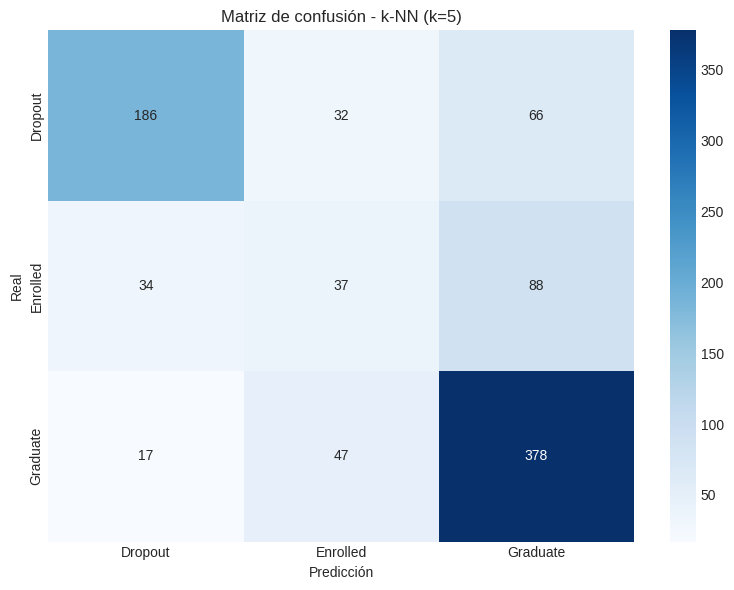

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión - k-NN (k=5)')
plt.tight_layout()
plt.show()

### 4.2 Selección del hiperparámetro k

**Justificación:** k demasiado pequeño puede causar overfitting; k demasiado grande puede suavizar demasiado la frontera. Usamos validación cruzada para encontrar el k óptimo.

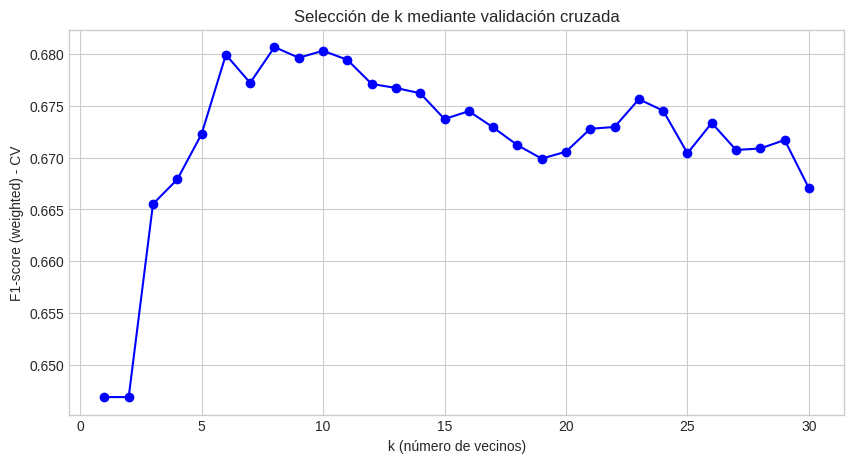


Mejor k: 8 (F1-score: 0.6806)


In [23]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, weights='distance')
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='f1_weighted')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, 'bo-')
plt.xlabel('k (número de vecinos)')
plt.ylabel('F1-score (weighted) - CV')
plt.title('Selección de k mediante validación cruzada')
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(cv_scores)]
print(f"\nMejor k: {best_k} (F1-score: {max(cv_scores):.4f})")

### 4.3 Búsqueda por Grid Search (opcional)

Refinamos la búsqueda con más hiperparámetros: k, weights y métrica.

In [24]:
param_grid = {
    'n_neighbors': [5, 10, 15, 20, 25, 30],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(), param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor F1-score (CV):", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
Mejor F1-score (CV): 0.7054


In [25]:
best_knn = grid_search.best_estimator_
y_pred_final = best_knn.predict(X_test_scaled)

print("\nMétricas finales en conjunto de prueba:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_final), 4))
print("F1-score (weighted):", round(f1_score(y_test, y_pred_final, average='weighted'), 4))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_final, target_names=class_names))


Métricas finales en conjunto de prueba:
Accuracy: 0.7198
F1-score (weighted): 0.6981

Reporte de clasificación:
              precision    recall  f1-score   support

     Dropout       0.84      0.64      0.73       284
    Enrolled       0.44      0.26      0.33       159
    Graduate       0.72      0.94      0.81       442

    accuracy                           0.72       885
   macro avg       0.67      0.61      0.62       885
weighted avg       0.71      0.72      0.70       885



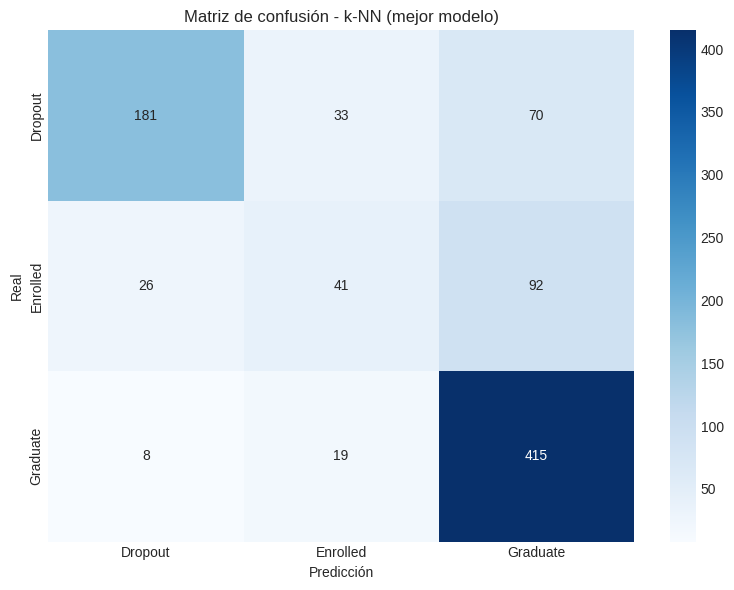

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión - k-NN (mejor modelo)')
plt.tight_layout()
plt.show()

---

## 5. Conclusiones

1. **Dataset:** Se utilizó el dataset UCI (ID 697) con 4,424 instancias y 36 características. No hay valores faltantes.

2. **Desbalance de clases:** El dataset presenta desbalance hacia una de las clases (Dropout/Enrolled/Graduate). Se usó F1-score ponderado para evaluar mejor el rendimiento en clases minoritarias.

3. **Preprocesamiento:** Estandarización con StandardScaler para que k-NN no dependa de la escala de las variables.

4. **Modelo k-NN:** Adecuado para clasificación multiclase. La búsqueda por Grid Search permitió encontrar la combinación óptima de k, weights y métrica.

5. **Limitaciones:** k-NN puede ser costoso en predicción con muchos datos. Para producción, considerar modelos más eficientes o reducción de dimensionalidad.

---

*Notebook generado para el Proyecto Integrador 2.10 - k-NN*